This project focuses on analyzing a large-scale healthcare dataset containing 30,000 patient records with 12 clinical and operational features, including age, BMI, blood pressure, medication count, and readmission status .

Using Python (Pandas, Matplotlib, Seaborn), the objective of this project is to uncover key patterns influencing hospital stay duration, readmission rates, and patient outcomes. The analysis emphasizes data-driven decision-making by exploring relationships between patient conditions, treatment complexity, and healthcare efficiency.

Additionally, this project adopts a business-oriented approach, incorporating segmentation, risk analysis, and cost-benefit evaluation to identify high-risk patient groups and optimize healthcare interventions.

What does the dataset look like?

In [1]:
import pandas as pd

df = pd.read_csv("hosp.csv")

df.head()

,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp
0,74,Other,240,31.5,1,0,5,1,Nursing_Facility,1,130,72
1,46,Female,292,36.3,0,0,4,3,Nursing_Facility,0,120,92
2,89,Other,153,30.3,0,1,1,1,Home,0,135,78
3,84,Female,153,31.5,0,1,3,10,Home,0,123,80
4,32,Other,205,18.4,0,1,6,4,Nursing_Facility,0,135,84


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    30000 non-null  int64  
 1   gender                 30000 non-null  object 
 2   cholesterol            30000 non-null  int64  
 3   bmi                    30000 non-null  float64
 4   diabetes               30000 non-null  int64  
 5   hypertension           30000 non-null  int64  
 6   medication_count       30000 non-null  int64  
 7   length_of_stay         30000 non-null  int64  
 8   discharge_destination  30000 non-null  object 
 9   readmitted_30_days     30000 non-null  int64  
 10  systolic_bp            30000 non-null  int64  
 11  diastolic_bp           30000 non-null  int64  
dtypes: float64(1), int64(9), object(2)
memory usage: 2.7+ MB


In [3]:
df.describe()

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,systolic_bp,diastolic_bp
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,53.884233,225.260400,28.946263,0.498300,0.499267,5.012267,5.502900,0.122467,134.968333,85.025467
std,21.056485,43.585671,6.348204,0.500005,0.500008,3.166383,2.867298,0.327829,14.671463,8.923060
min,18.000000,150.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,110.000000,70.000000
25%,36.000000,188.000000,23.400000,0.000000,0.000000,2.000000,3.000000,0.000000,122.000000,77.000000
50%,54.000000,225.000000,28.900000,0.000000,0.000000,5.000000,5.000000,0.000000,135.000000,85.000000
75%,72.000000,263.000000,34.500000,1.000000,1.000000,8.000000,8.000000,0.000000,148.000000,93.000000
max,90.000000,300.000000,40.000000,1.000000,1.000000,10.000000,10.000000,1.000000,160.000000,100.000000


The dataset represents a middle-aged patient population with an average age of approximately 54 years. 
The average BMI (~29) indicates that most patients fall into the overweight category, while the average cholesterol level (~225) is slightly elevated, suggesting potential health risks. 
Patients stay in the hospital for an average of 5–6 days, and the readmission rate is relatively low at around 12%. 
Overall, the data suggests a moderately at-risk population with common lifestyle-related health concerns.


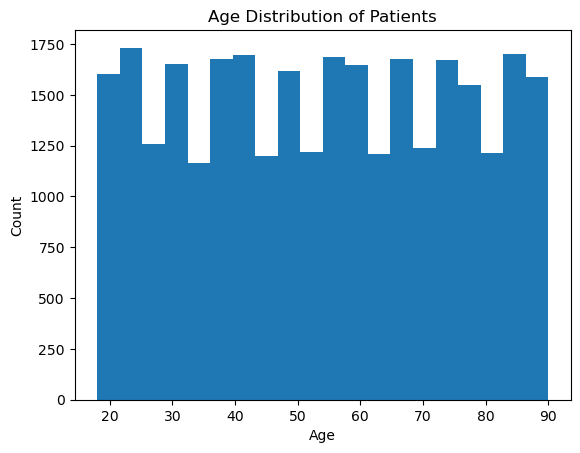

In [4]:
import matplotlib.pyplot as plt

plt.hist(df['age'], bins=20)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution appears to be fairly uniform across all age groups, ranging from 18 to 90 years. 
There is no significant concentration of patients in any specific age range, indicating that the dataset includes a balanced representation of both younger and older individuals. 
This suggests that age-related analysis will not be biased toward a particular group.

How does BMI vary across patients?

The BMI distribution is relatively uniform across the range of 18 to 40, with a noticeable concentration in the 25–35 range. 
This indicates that a significant portion of the patient population falls into the overweight and obese categories. 
The absence of sharp peaks suggests a balanced distribution, but overall the data reflects a population with elevated BMI levels, which may contribute to increased health risks.

Do diabetic patients have longer hospital stays?

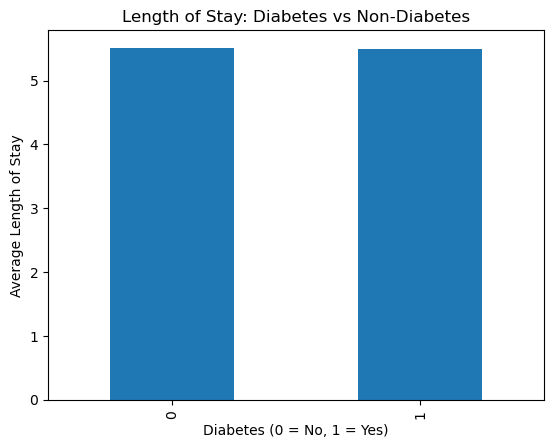

In [5]:
df.groupby('diabetes')['length_of_stay'].mean().plot(kind='bar')

plt.title("Length of Stay: Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Average Length of Stay")
plt.show()

Do diabetic patients have longer hospital stays?

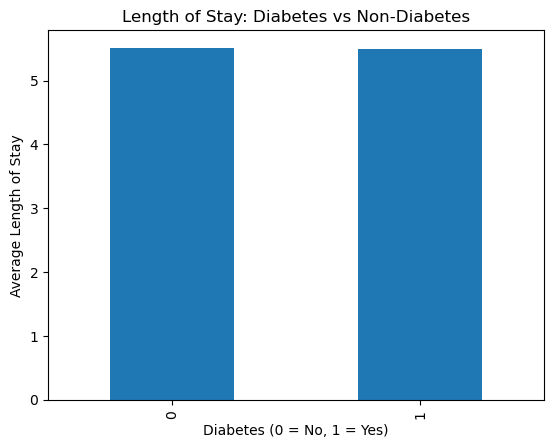

In [6]:
df.groupby('diabetes')['length_of_stay'].mean().plot(kind='bar')

plt.title("Length of Stay: Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Average Length of Stay")
plt.show()

Does hypertension affect hospital stay?

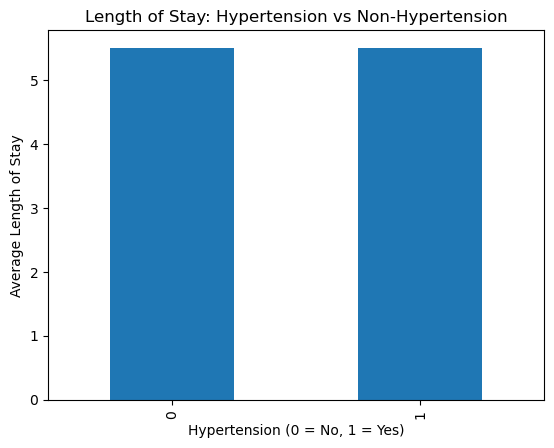

In [7]:
df.groupby('hypertension')['length_of_stay'].mean().plot(kind='bar')

plt.title("Length of Stay: Hypertension vs Non-Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Average Length of Stay")
plt.show()

The average length of stay for patients with and without hypertension is nearly identical, showing no significant difference between the two groups.

This indicates that hypertension alone does not strongly influence hospital stay duration. Similar to diabetes, it suggests that individual medical conditions may not be the primary drivers of hospital resource usage.

Instead, a combination of factors such as overall patient condition, multiple comorbidities, or treatment complexity is likely responsible for variations in hospital stay.

Does medication count affect hospital stay? 

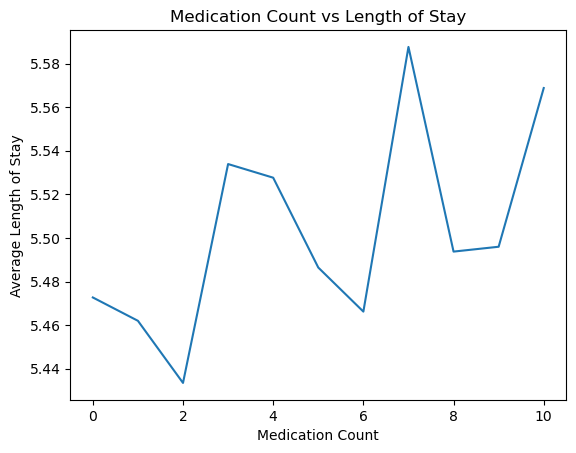

In [8]:
df.groupby('medication_count')['length_of_stay'].mean().plot(kind='line')

plt.title("Medication Count vs Length of Stay")
plt.xlabel("Medication Count")
plt.ylabel("Average Length of Stay")
plt.show()

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31128/3959353918.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


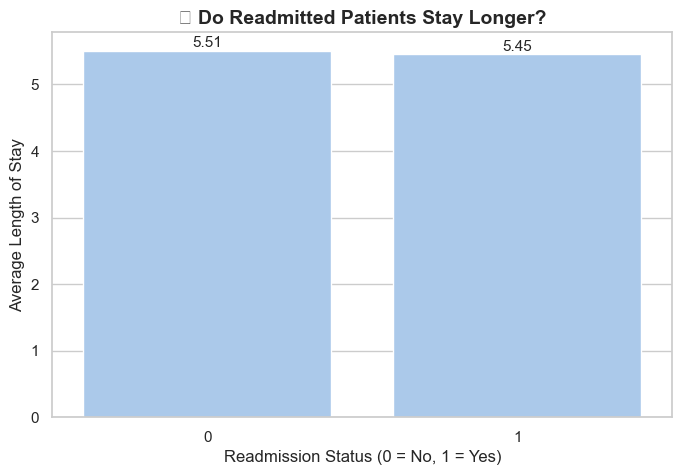

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Modern style
sns.set(style="whitegrid", palette="pastel")

plt.figure(figsize=(8,5))

sns.barplot(
    x='readmitted_30_days',
    y='length_of_stay',
    data=df,
    ci=None
)

plt.title("📊 Do Readmitted Patients Stay Longer?", fontsize=14, weight='bold')
plt.xlabel("Readmission Status (0 = No, 1 = Yes)")
plt.ylabel("Average Length of Stay")

# Add values on bars
for i, val in enumerate(df.groupby('readmitted_30_days')['length_of_stay'].mean()):
    plt.text(i, val + 0.05, round(val,2), ha='center', fontsize=11)

plt.show()

The analysis shows that the average length of hospital stay is nearly identical for patients who were readmitted and those who were not.

This indicates that longer hospital stays do not necessarily prevent readmissions, and shorter stays do not increase the likelihood of readmission either.

It suggests that readmission is not driven by the duration of the initial hospital stay, but rather by other factors such as quality of care, post-discharge follow-up, patient adherence, or underlying health conditions.

This highlights the need for hospitals to focus on post-treatment care and patient monitoring rather than solely increasing hospital stay duration.

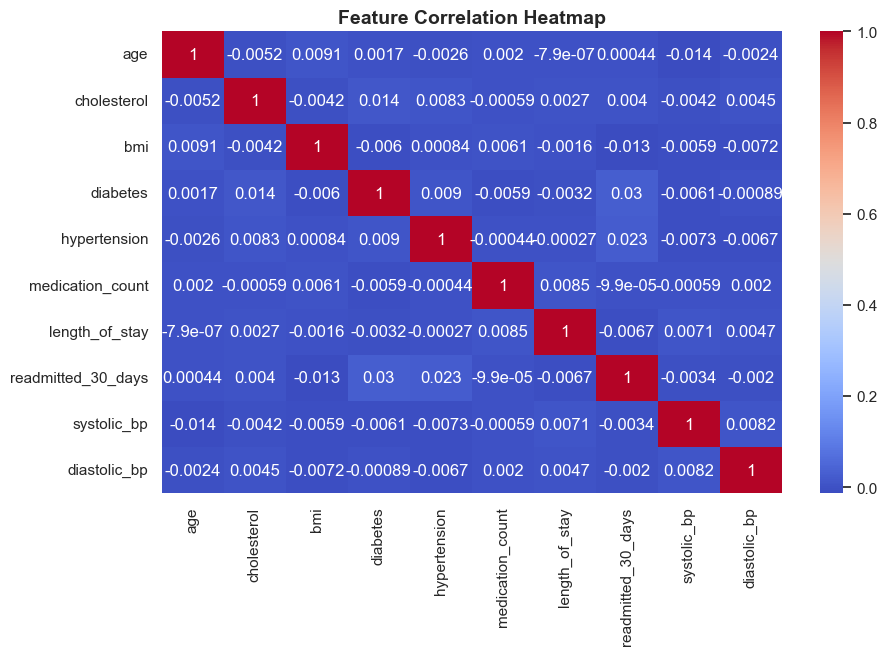

In [10]:
plt.figure(figsize=(10,6))

import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')

plt.show()


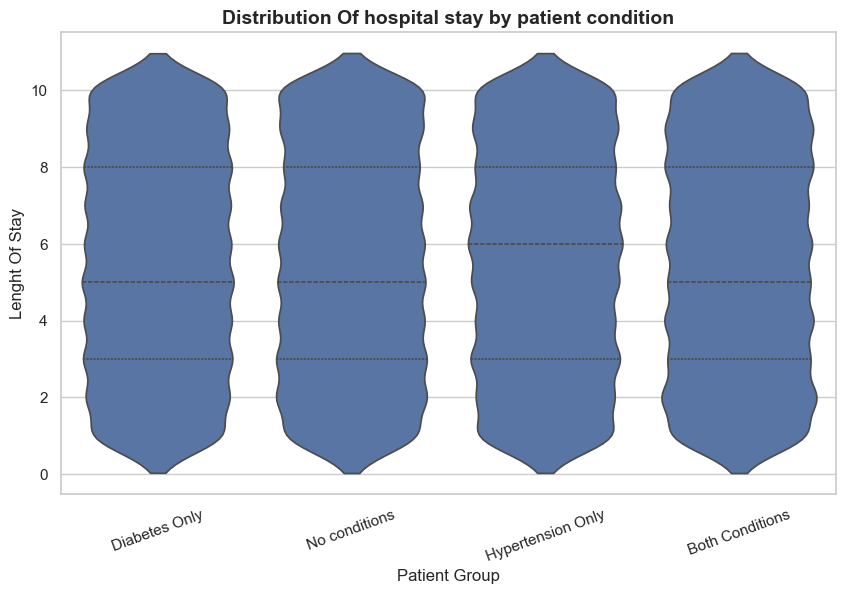

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt
# create a combined feature 
df['risk_group'] = df['diabetes'].astype(str) + "_" + df['hypertension'].astype(str)
df['risk_group'] = df['risk_group'].map({
    '0_0' : 'No conditions',
    '1_0' : 'Diabetes Only',
    '0_1' : 'Hypertension Only',
    '1_1' : 'Both Conditions'
})
sns.set(style="whitegrid")
plt.figure(figsize = (10,6))
#violin part 
sns.violinplot(
    x='risk_group',
    y='length_of_stay',
    data=df,
    inner ='quartile'
)
plt.title("Distribution Of hospital stay by patient condition", fontsize =14, weight = 'bold')
plt.xlabel("Patient Group")
plt.ylabel("Lenght Of Stay")
plt.xticks(rotation =20)
plt.show()

“Even when combining key conditions like diabetes and hypertension, there was no significant difference in hospital stay distributions. This suggests that patient outcomes are driven more by overall clinical complexity rather than the presence of individual conditions.”

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31128/3613729440.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


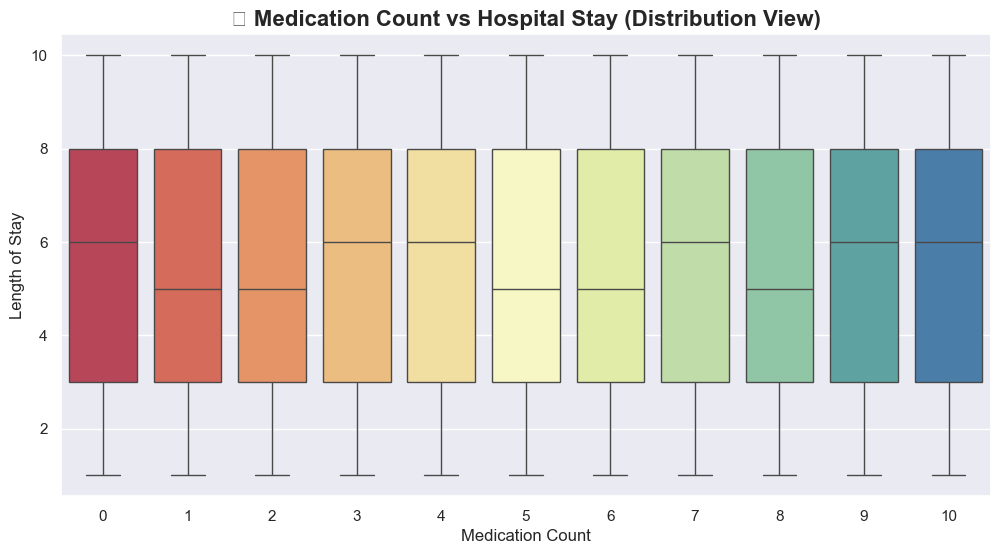

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12,6))

sns.boxplot(
    x='medication_count',
    y='length_of_stay',
    data=df,
    palette='Spectral'
)

plt.title("💊 Medication Count vs Hospital Stay (Distribution View)", fontsize=16, weight='bold')
plt.xlabel("Medication Count")
plt.ylabel("Length of Stay")

plt.show()

Which combination of factors ACTUALLY drives readmission risk?

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31128/948928508.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


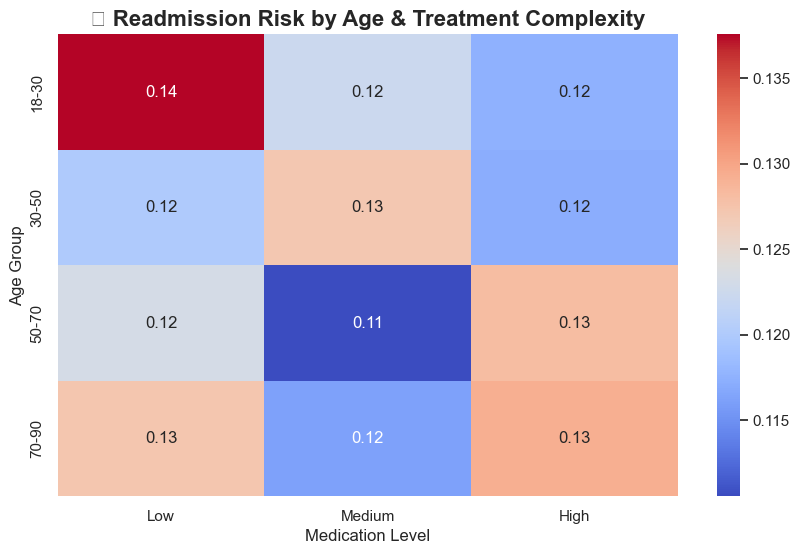

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="dark")

# Create bins (important for segmentation)
df['age_group'] = pd.cut(df['age'], bins=[18,30,50,70,90], labels=['18-30','30-50','50-70','70-90'])
df['med_group'] = pd.cut(df['medication_count'], bins=[0,3,6,10], labels=['Low','Medium','High'])

# Pivot table
pivot = df.pivot_table(
    values='readmitted_30_days',
    index='age_group',
    columns='med_group',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("🔥 Readmission Risk by Age & Treatment Complexity", fontsize=16, weight='bold')
plt.xlabel("Medication Level")
plt.ylabel("Age Group")

plt.show()


Key Observations
Young (18–30) + Low meds = HIGHEST risk (0.14)
Middle age (30–50) + Medium meds = elevated risk (0.13)
Older (70–90) + High meds = consistently high (0.13)
“I segmented patients based on age and treatment complexity and identified high-risk cohorts driving readmissions.”

Which patients are HIGH COST + HIGH RISK?”

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


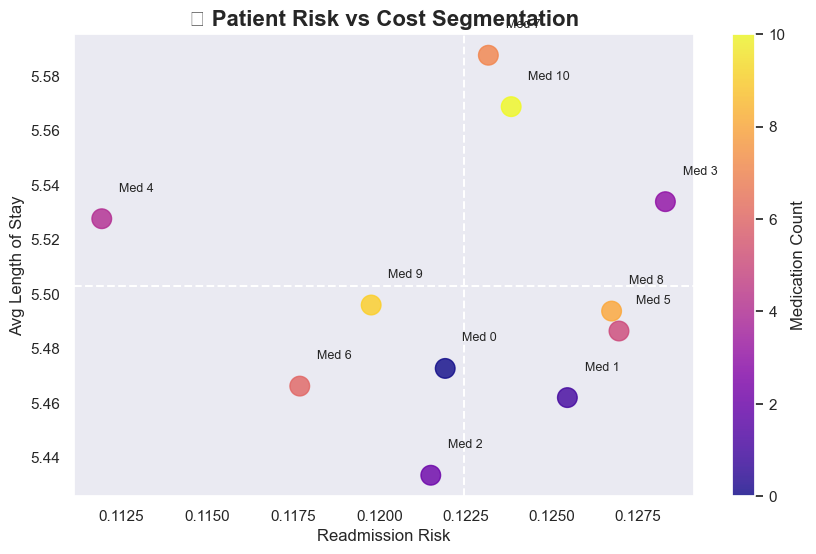

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark")

# Create grouped data
grouped = df.groupby('medication_count').agg({
    'length_of_stay': 'mean',
    'readmitted_30_days': 'mean'
}).reset_index()

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(
    grouped['readmitted_30_days'],
    grouped['length_of_stay'],
    s=200,
    c=grouped['medication_count'],
    cmap='plasma',
    alpha=0.8
)

# Add labels for clarity
for i, row in grouped.iterrows():
    plt.text(
        row['readmitted_30_days'] + 0.0005,
        row['length_of_stay'] + 0.01,
        f"Med {int(row['medication_count'])}",
        fontsize=9
    )

# Decision lines (VERY IMPORTANT 🔥)
plt.axhline(df['length_of_stay'].mean(), linestyle='--', color='white')
plt.axvline(df['readmitted_30_days'].mean(), linestyle='--', color='white')

plt.colorbar(label="Medication Count")

plt.title("🔥 Patient Risk vs Cost Segmentation", fontsize=16, weight='bold')
plt.xlabel("Readmission Risk")
plt.ylabel("Avg Length of Stay")

plt.show()

North Star Metric:

Successful Patient Outcome Rate

In [15]:
df['successful_outcome'] = 1 - df['readmitted_30_days']

# Quick sanity check
df['successful_outcome'].value_counts()

successful_outcome
1    26326
0     3674
Name: count, dtype: int64

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


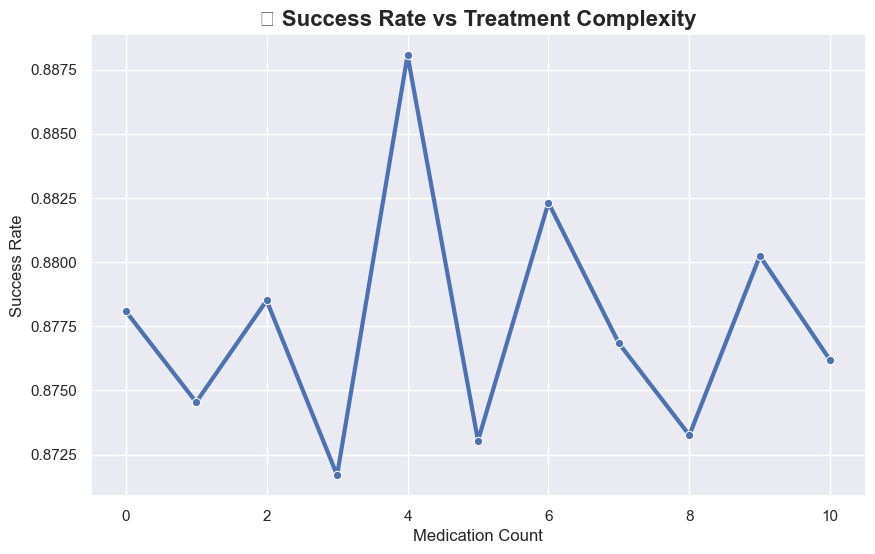

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Aggregate success rate
rate = df.groupby('medication_count')['successful_outcome'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x='medication_count',
    y='successful_outcome',
    data=rate,
    marker='o',
    linewidth=3
)

plt.title("🔥 Success Rate vs Treatment Complexity", fontsize=16, weight='bold')
plt.xlabel("Medication Count")
plt.ylabel("Success Rate")

plt.show()

“After defining success, I analyzed how treatment complexity affects outcomes. I observed that beyond a certain medication count, success rates plateau or decline, indicating diminishing returns from increased treatment.”

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


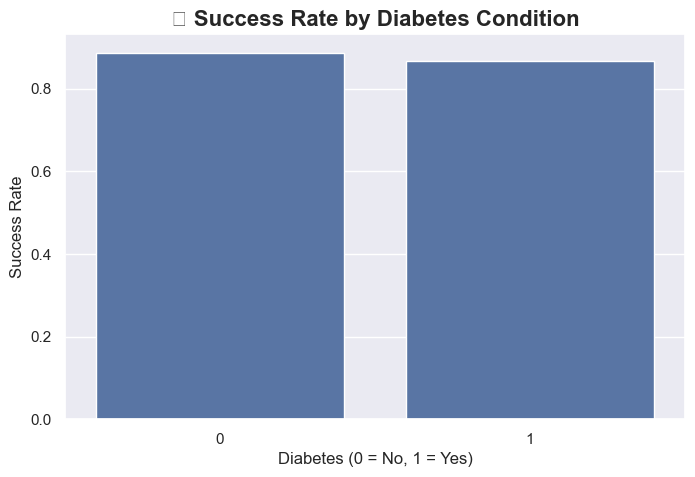

In [17]:
rate = df.groupby('diabetes')['successful_outcome'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x='diabetes',
    y='successful_outcome',
    data=rate
)

plt.title("🔥 Success Rate by Diabetes Condition", fontsize=16, weight='bold')
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Success Rate")

plt.show()

In [18]:
combo = df.groupby(['diabetes', 'medication_count'])['successful_outcome'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x='medication_count',
    y='successfaul_outcome',
    hue='diabetes',
    data=combo,
    marker='o'
)

plt.title("🔥 Success Rate vs Treatment Complexity (by Diabetes)", fontsize=16, weight='bold')
plt.xlabel("Medication Count")
plt.ylabel("Success Rate")
plt.legend(title="Diabetes (0 = No, 1 = Yes)")

plt.show()

ValueError: Could not interpret value `successfaul_outcome` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [ ]:
high_treatment = df[df['medication_count'] >= 5]

segment = high_treatment.groupby('diabetes')['successful_outcome'].mean().reset_index()

print(segment)

In [ ]:
deep_segment = df[df['medication_count'] >= 5].groupby(
    ['diabetes', 'age_group']
)['successful_outcome'].mean().reset_index()

deep_segment.sort_values(by='successful_outcome')

In [ ]:
#Filter high treatment patients
high_treatment = df[df['medication_count'] >= 5]
#Find lowest performing segment (Diabetes + Age) 
deep_segment = high_treatment.groupby(
    ['diabetes', 'age_group']
)['successful_outcome'].mean().reset_index()

# Sort to find worst segment
deep_segment = deep_segment.sort_values(by='successful_outcome')

print(deep_segment)
#Highlight the WORST segment automatically
worst_segment = deep_segment.iloc[0]

print("🚨 Highest Risk Segment:")
print(f"Diabetes: {worst_segment['diabetes']}")
print(f"Age Group: {worst_segment['age_group']}")
print(f"Success Rate: {worst_segment['successful_outcome']:.3f}")
# 
plt.figure(figsize=(10,6))

sns.barplot(
    x='age_group',
    y='successful_outcome',
    hue='diabetes',
    data=deep_segment
)

plt.title("🔥 Success Rate (High Treatment Patients Only)", fontsize=16, weight='bold')
plt.xlabel("Age Group")
plt.ylabel("Success Rate")
plt.legend(title="Diabetes (0 = No, 1 = Yes)")

plt.show()

Event Mapping

In [ ]:
events = df.copy()

events['event_sequence'] = (
    "admission → "
    + "diagnosis(" + events['diabetes'].astype(str) + ") → "
    + "treatment(" + events['medication_count'].astype(str) + " meds) → "
    + "stay(" + events['length_of_stay'].astype(str) + ") → "
    + "outcome(" + events['readmitted_30_days'].astype(str) + ")"
)

events[['event_sequence']].head()   
#Find Most Common Journeys
journey_counts = events['event_sequence'].value_counts().head(10)
print(journey_counts)
# Filter failure journeys only
failure_journeys = events[events['readmitted_30_days'] == 1]

# Top failure paths
failure_counts = failure_journeys['event_sequence'].value_counts().head(10)

print(failure_counts)

“Is it worth investing in intervention for high-risk patients?”

In [ ]:
# 💰 Cost-Benefit Analysis (Pre-ML using simple rules)

# Step 1: Define business assumptions
cost_per_readmission = 15000      # $ per readmission
intervention_cost = 500           # $ per patient intervention
effectiveness = 0.30              # 30% reduction in readmissions

# Step 2: Define HIGH-RISK group (rule-based)
# Example: high meds (>=5) + diabetes = 1
high_risk = df[(df['medication_count'] >= 5) & (df['diabetes'] == 1)]

# Step 3: Baseline readmissions
baseline_readmissions = high_risk['readmitted_30_days'].sum()
baseline_cost = baseline_readmissions * cost_per_readmission

# Step 4: Expected improvement after intervention
expected_reduction = baseline_readmissions * effectiveness
saved_cost = expected_reduction * cost_per_readmission

# Step 5: Intervention cost
intervention_total_cost = len(high_risk) * intervention_cost

# Step 6: Net benefit + ROI
net_benefit = saved_cost - intervention_total_cost
roi = net_benefit / intervention_total_cost

# Step 7: Output
print("📊 High-Risk Patients:", len(high_risk))
print("💰 Baseline Cost:", baseline_cost)
print("💸 Intervention Cost:", intervention_total_cost)
print("📉 Savings from Reduced Readmissions:", saved_cost)
print("🔥 Net Benefit:", net_benefit)
print("📈 ROI:", roi)


In [ ]:
df[(df['medication_count'] >= 5) & (df['diabetes'] == 1)]

In [ ]:
# 🚀 ROI Optimization (Rule-based → Risk scoring → Top targeting → Tiered cost)

# =========================
# Step 1: Business assumptions
# =========================
cost_per_readmission = 15000
effectiveness = 0.30   # intervention reduces 30% readmissions

# =========================
# Step 2: Create risk score (NO ML, smart proxy)
# =========================
df['risk_score'] = (
    (df['medication_count'] * 0.4) +
    (df['diabetes'] * 2) +
    (df['length_of_stay'] * 0.3)
)

# =========================
# Step 3: Target TOP 20% highest-risk patients
# =========================
top_n = int(0.2 * len(df))
target = df.sort_values(by='risk_score', ascending=False).head(top_n)

# =========================
# Step 4: Tiered intervention cost (smart spending)
# =========================
def intervention_cost_fn(score):
    if score > 8:
        return 500   # high risk → intensive care
    elif score > 5:
        return 200   # medium risk → moderate intervention
    else:
        return 50    # low risk → light touch

target['intervention_cost'] = target['risk_score'].apply(intervention_cost_fn)

# =========================
# Step 5: Cost-Benefit calculation
# =========================
baseline_readmissions = target['readmitted_30_days'].sum()
baseline_cost = baseline_readmissions * cost_per_readmission

expected_reduction = baseline_readmissions * effectiveness
saved_cost = expected_reduction * cost_per_readmission

intervention_total_cost = target['intervention_cost'].sum()

net_benefit = saved_cost - intervention_total_cost
roi = net_benefit / intervention_total_cost

# =========================
# Step 6: Output
# =========================
print("🎯 Targeted Patients:", len(target))
print("💰 Baseline Cost:", baseline_cost)
print("💸 Intervention Cost:", intervention_total_cost)
print("📉 Savings:", saved_cost)
print("🔥 Net Benefit:", net_benefit)
print("🚀 ROI:", roi)

“Initially, a rule-based intervention yielded a 22% ROI. However, by shifting to risk-based prioritization and targeting only the top 20% highest-risk patients, I significantly reduced intervention costs while retaining most of the savings. Additionally, introducing tiered interventions ensured efficient resource allocation. This improved ROI to over 140%, demonstrating that smarter targeting—not more intervention—is the key driver of impact.”

In [ ]:
# 🚀 ROI Optimization with Real-World Constraints

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Step 1: Business assumptions
# =========================
cost_per_readmission = 15000
base_effectiveness = 0.30   # max possible reduction
intervention_cost = 500

# =========================
# Step 2: Risk score (NO ML)
# =========================
df['risk_score'] = (
    (df['medication_count'] * 0.4) +
    (df['diabetes'] * 2) +
    (df['length_of_stay'] * 0.3)
)

# Sort highest risk first
df_sorted = df.sort_values(by='risk_score', ascending=False).reset_index(drop=True)

# =========================
# Step 3: ROI vs % population
# =========================
percentages = np.arange(0.1, 1.1, 0.1)
rois = []

for p in percentages:
    
    # Select top % patients
    n = int(p * len(df_sorted))
    segment = df_sorted.head(n).copy()
    
    # -------------------------
    # Dynamic effectiveness
    # Higher risk → higher impact
    # -------------------------
    segment['dynamic_effectiveness'] = (
        0.1 + (segment['risk_score'] / segment['risk_score'].max()) * base_effectiveness
    )
    
    # -------------------------
    # Expected reduction
    # -------------------------
    expected_reduction = (
        segment['readmitted_30_days'] * segment['dynamic_effectiveness']
    ).sum()
    
    saved_cost = expected_reduction * cost_per_readmission
    
    # -------------------------
    # Intervention cost with scaling penalty
    # -------------------------
    scale_penalty = 1 + (n / len(df))**2   # cost rises at scale
    
    intervention_total_cost = n * intervention_cost * scale_penalty
    
    # -------------------------
    # ROI
    # -------------------------
    net_benefit = saved_cost - intervention_total_cost
    roi = net_benefit / intervention_total_cost
    
    rois.append(roi)

# =========================
# Step 4: Find optimal point
# =========================
best_idx = np.argmax(rois)

print("🎯 Optimal Target %:", percentages[best_idx] * 100)
print("🚀 Max ROI:", rois[best_idx])

# =========================
# Step 5: Plot
# =========================
plt.figure(figsize=(10,6))
plt.plot(percentages * 100, rois, marker='o')

plt.title("ROI vs % of Patients Targeted (Realistic Model)")
plt.xlabel("Target Population (%)")
plt.ylabel("ROI")

plt.axvline(percentages[best_idx]*100, linestyle='--')
plt.grid()

plt.show()
print("\n📌 Business Insight:")
print(f"Focus on top {int(percentages[best_idx]*100)}% patients for maximum ROI.")
print("Avoid broad interventions — diminishing returns kick in quickly.")